# Simulated Spectral Reduction - Echelle Spectrograph

    Created: Ethan Bull, June 2024
    Edited: C.Worley, July 2025
    Edited: C.Worley, May 2026

This tutorial introduces students to spectral reduction for an echelle spectrograph.

The data is a simulated spectral image containing data for a star that has parameters similar to the star 'μ Ara'.

In [164]:
# Import the python modules you will need. You can use others, but the entire lab can be done with these.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
import scipy as sp
import matplotlib.colors as colors
from scipy.optimize import curve_fit


%matplotlib inline

# 1. Define the Gaussian function
def gaussian(x, amplitude, mean, stddev):
    return amplitude * np.exp(-((x - mean) / stddev)**2 / 2)


## Task 1: Opening and inspecting the data
The data to be used in this tutorial are located on the MacDiarmid server in: ??/ASTR211/2025_Lab_Files/Spectroscopy/Reduction_1/

There are three fits files in this folder associated with this tutorial:
- 'simspe_mu_ara.fits'
- 'simspe_dark.fits'
- 'simspe_thar.fits'

These files contain data in the form that an echelle spectrograph would produce. More on echelles in lectures. We will use these files to generate the spectrum of a star (i.e. flux versus wavelength).

Follow these steps to open and display the data from each file:
1. Start with the raw data. Open the fits file using code from Lab 2 or Lab 3.
2. Extract the data from the first extension (1 when indexing in python).
3. Plot the data. Don't forget titles.
4. Repeat steps 1-3 for the dark and thar (thorium) files.

220793.0 960.0


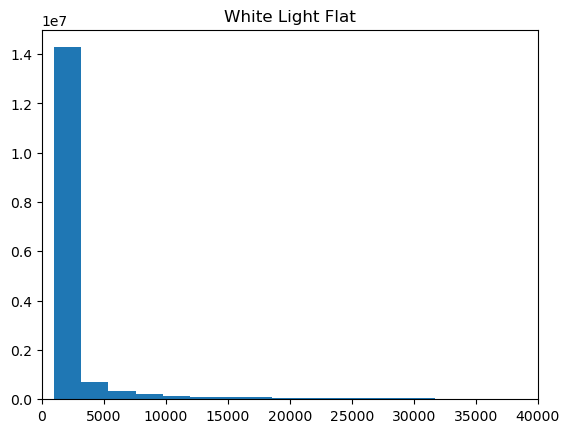

56728 968


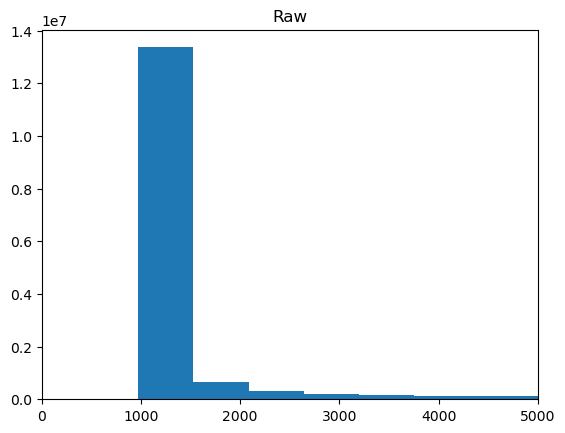

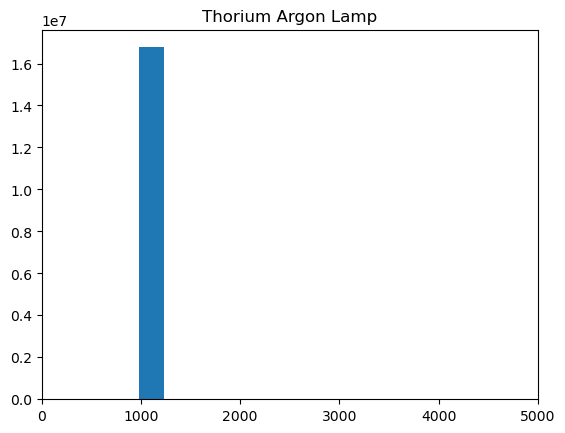

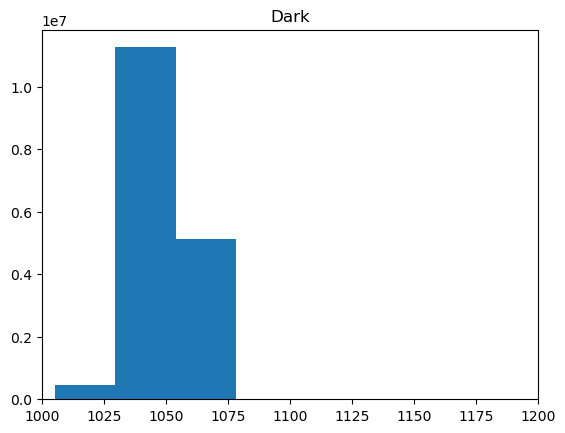

In [73]:
#folder = '/Volumes/ASTR211/2025_Lab_Files/Spectroscopy/Reduction_1/'
folder = '/Users/ccw31/Documents/Data/HERCULES/20260501/'

whitefile = folder + 'J1162010.fit'
hdul = fits.open(whitefile)
white = hdul[0].data 
hdul.close()

rawfile = folder + 'J1162019.fit'
hdul = fits.open(rawfile)
raw = hdul[0].data 
hdul.close()

tharfile = folder + 'J1162016.fit'
hdul = fits.open(tharfile)
thar = hdul[0].data 
hdul.close()

darkfile = folder + 'J1162032.fit'
hdul = fits.open(darkfile)
dark = hdul[0].data 
hdul.close()

print(np.max(white),np.min(white))
plt.hist(white.flatten(),bins=100)
plt.title('White Light Flat')
plt.xlim(0,40000)
plt.show()

print(np.max(raw),np.min(raw))
plt.hist(raw.flatten(),bins=100)
plt.title('Raw')
plt.xlim(0,5000)
plt.show()

plt.hist(thar.flatten(),bins=1000)
plt.title('Thorium Argon Lamp')
plt.xlim(0,5000)
plt.show()

plt.hist(dark.flatten(),bins=100)
plt.title('Dark')
plt.xlim(1000,1200)
plt.show()


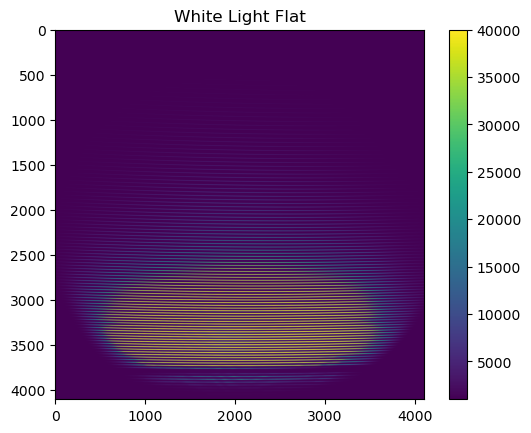

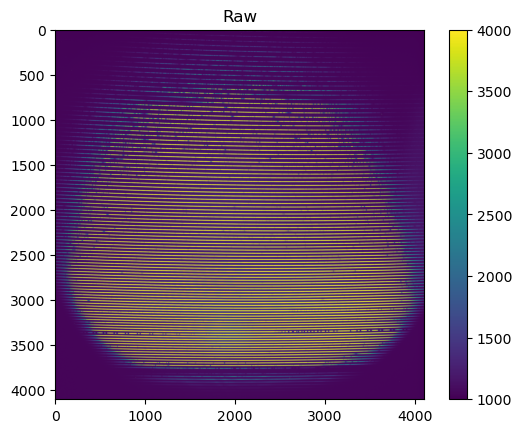

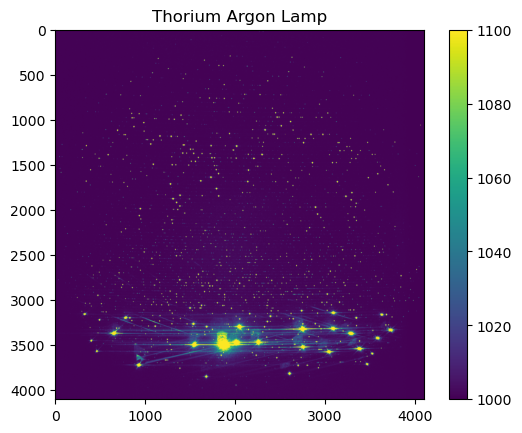

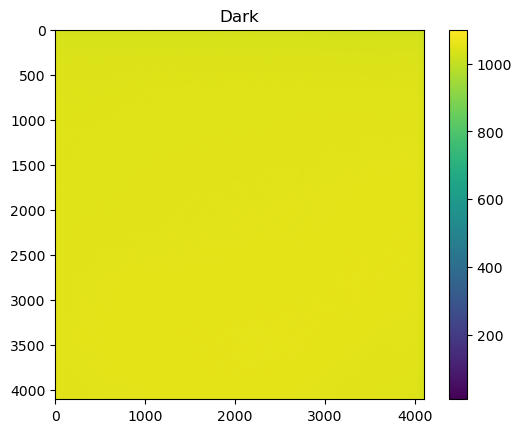

In [74]:

plt.imshow(white,vmin=1000,vmax=40000) #,norm=colors.LogNorm(vmin=1000, vmax=4000))
plt.title('White Light Flat')
plt.colorbar()
plt.show()

plt.imshow(raw,vmin=1000,vmax=4000) #,norm=colors.LogNorm(vmin=1000, vmax=4000))
plt.title('Raw')
plt.colorbar()
plt.show()

plt.imshow(thar,vmin=1000,vmax=1100)
plt.title('Thorium Argon Lamp')
plt.colorbar()
plt.show()

plt.imshow(dark,vmin=10,vmax=1100)
plt.title('Dark')
plt.colorbar()
plt.show()

(4108, 4096)


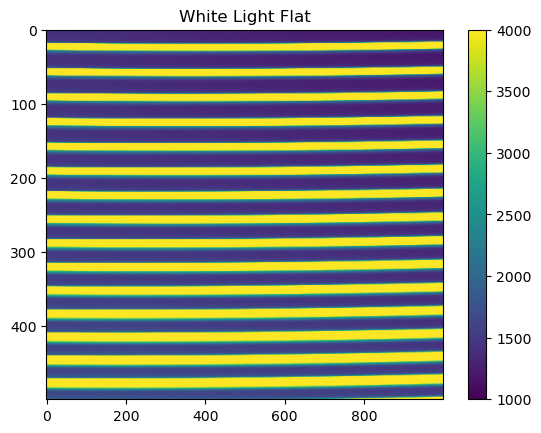

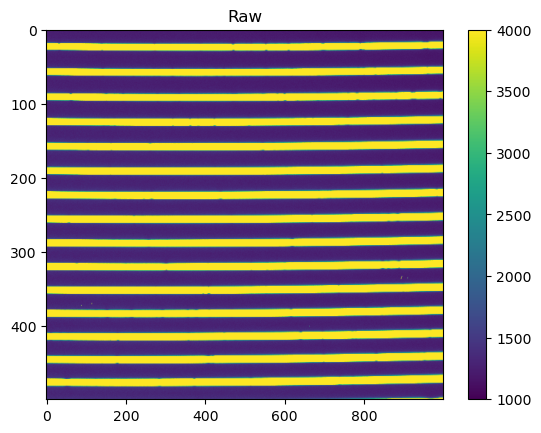

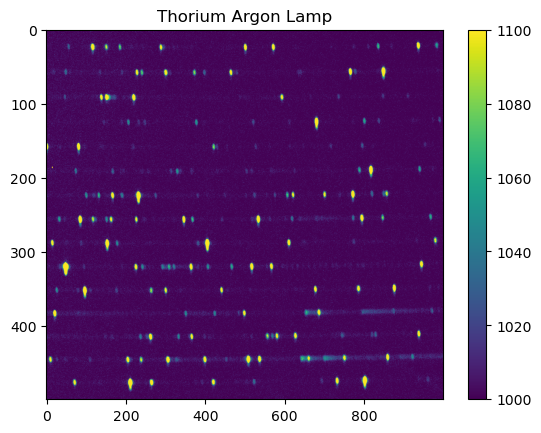

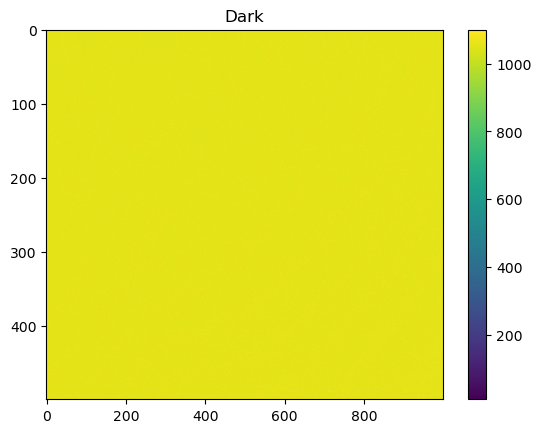

In [187]:
nshape = white.shape
print(nshape)

xmin = 2500 #2500
xmax = 3000 #2700
ymin = 2000 #0
ymax = 3000 #nshape[0]

white_region = white[xmin:xmax, ymin:ymax]
raw_region = raw[xmin:xmax, ymin:ymax]
thar_region = thar[xmin:xmax, ymin:ymax]
dark_region = dark[xmin:xmax, ymin:ymax]

plt.imshow(white_region,vmin=1000,vmax=4000, aspect='auto') #,norm=colors.LogNorm(vmin=1000, vmax=4000))
plt.title('White Light Flat')
plt.colorbar()
plt.show()

plt.imshow(raw_region,vmin=1000,vmax=4000, aspect='auto') #,norm=colors.LogNorm(vmin=1000, vmax=4000))
plt.title('Raw')
plt.colorbar()
plt.show()

plt.imshow(thar_region,vmin=1000,vmax=1100, aspect='auto')
plt.title('Thorium Argon Lamp')
plt.colorbar()
plt.show()

plt.imshow(dark_region,vmin=10,vmax=1100, aspect='auto')
plt.title('Dark')
plt.colorbar()
plt.show()

The 'raw' data is not like what we've seen for photometry. There's no identifiable image, but rather a set of parallel 'orders'.

Each order is a section of wavelength, so that the 'x' pixels' map to 'wavelength' not sky coordinate as for photometry.

But the pixels are still collecting light, as for photometry, and that light has signal from the object AND noise from the telescope/instrument system that we need to remove.

## Task 2: Dark Subtraction of Raw Image

We will do a basic reduction of the raw image by subtracting the dark image from the raw image.

In the next cell, subtract the dark from the raw image to get the dark-subtracted raw image.

Plot the dark-subtracted raw image using imshow.


47477 49


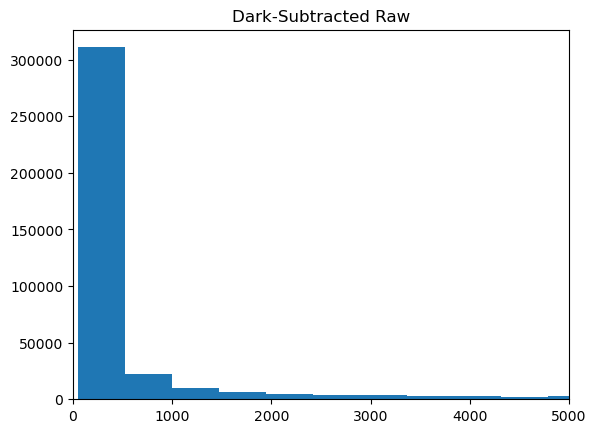

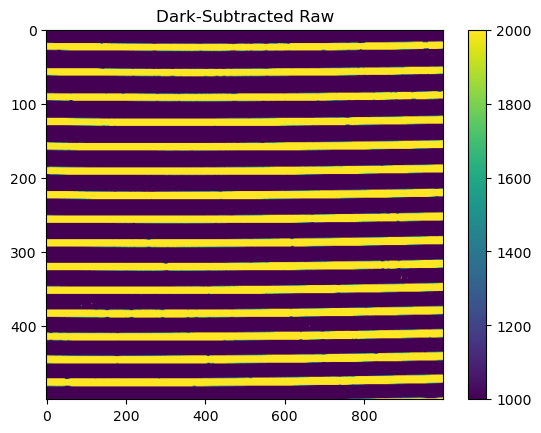

In [188]:
#Dark Subtraction
reduced_raw = raw_region - dark_region
#print(reduced_raw[:,900])
print(np.max(reduced_raw),np.min(reduced_raw))

plt.hist(reduced_raw.flatten(),bins=100)
plt.title('Dark-Subtracted Raw')
plt.xlim(0,5000)
plt.show()

# Plot Dark-Subtract-Raw
plt.imshow(reduced_raw,vmin=1000,vmax=2000, aspect='auto')
plt.title('Dark-Subtracted Raw')
plt.colorbar()
plt.show()



## Task 3: Inspect the 'y' coordinate location of the orders

We need to 'trace' each order in the image. Tracing means finding the 'x' and 'y' pixels that the order covers. We need the trace in order to convert the raw image from pixel space to wavelength space.

Follow these steps to create code that traces all of the orders:

1. Select an integer representing a 'column' (i.e. perpendicular to the orders) that crosses all the orders.
2. Use that integer to extract the corresponding column slice from the dark-subtracted raw image (recall Lab 1, Part 1 and slicing arrays).
3. Plot the column slice that you have extracted. Can you visually confirm where the orders are located in terms of a typical 'y' coordinate in the dark-subtracted raw image?

Discuss these locations with a tutor/lecturer.


[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 241 242 243 244 245 24

Text(0, 0.5, 'Counts')

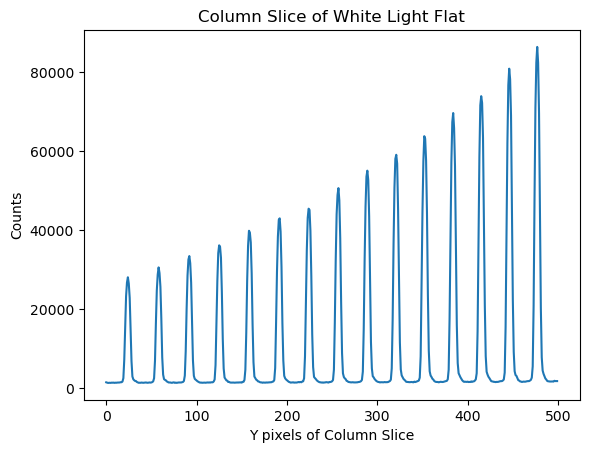

In [189]:
# # Selecting a vertical slice of the image
vertical_slice = white_region[:,250]
vertical_slice_pixvector = np.arange(len(vertical_slice))
print(vertical_slice_pixvector)



plt.plot(vertical_slice)
#plt.plot(vertical_slice_pixvector, gaussian(vertical_slice_pixvector, *popt), 'r--')
plt.title('Column Slice of White Light Flat')
plt.xlabel('Y pixels of Column Slice')
plt.ylabel('Counts')


## Task 4: Extract the 'y' location of the orders

While we have visually identified the location of the orders, we need the actual value of the 'y' pixel of each order.

The below cell is an example of doing thi using scipy's signal.find_peaks function. It will return index values ('y' pixel) at the location of the peaks in your column slice.

The output of the function, order_pixel_values, contains the 'y' pixel locations of each order.

Do these steps to confirm the trace location (example given):
1. Replot your column slice.
2. Use plt.axvline to overplot vertical lines for each location in order_pixel_values.
3. Add title and axis labels.

Do these steps to show the trace on the orders:
1. Replot your dark-subtract raw image using imshow
2. Use plt.axhline to overplot (now as) horizontal lines each trace from the locations in order_pixel_values.
3. Add title and axis labels.

Background level: 1792.0
Order pixel values: [ 24  58  92 125 158 192 224 257 289 321 352 384 415 446 477]


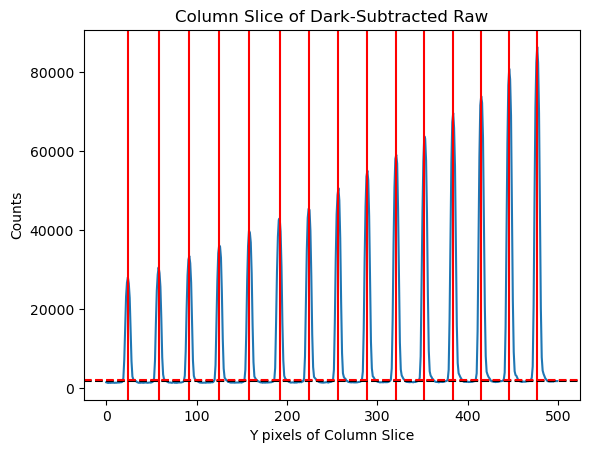

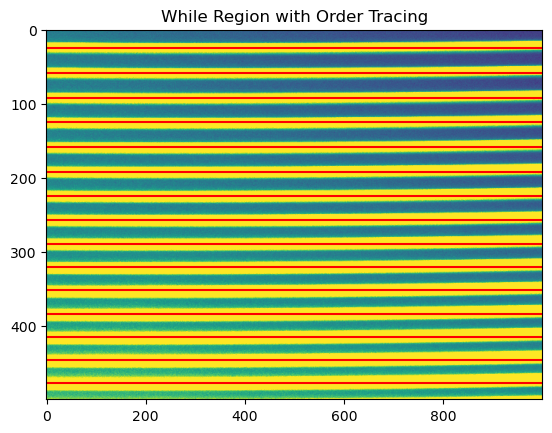

In [190]:
# Find background level in the vertical slice
background_level = np.median(vertical_slice)
nlevel = 1.2
print('Background level:', background_level)

# Find the peaks in your vertical slice
order_pixel_values, order_info = sp.signal.find_peaks(vertical_slice, height=background_level*nlevel, distance=10)
print('Order pixel values:', order_pixel_values)
#print('Order info:', order_info)

# Overplot the 'y' pixel locations as lines on the column slice
#print(order_pixel_values)
plt.plot(vertical_slice)
for line in order_pixel_values:
    plt.axvline(line,color='r')
    #plt.plot([line,line],[0,2500])
plt.axhline(background_level,color='k',linestyle='--')
plt.axhline(background_level*nlevel,color='r',linestyle='--')
plt.title('Column Slice of Dark-Subtracted Raw')
plt.xlabel('Y pixels of Column Slice')
plt.ylabel('Counts')
plt.show()

# Overplot the order trace on the Dark-Subtract Raw image.
plt.imshow(white_region,vmin=1000,vmax=2000, aspect='auto')
for line in order_pixel_values:
    #plt.plot([0,4000],[line,line])
    plt.axhline(line,color='r')
plt.title('While Region with Order Tracing')
plt.show()

You have just traced your orders!

Normally orders are not straight lines and require a higher order polynomial fit to trace the orders.

You were provided with values for 'height' and 'distance' in the signal.find_peaks function. Play around with these values. How do they affect the peak-finding? What do these values mean?

## Task 3: Extract one order to perform wavelength calibration

We will now focus on extracting and wavelength calibrating one order.

Scipy's find_peaks function has returned a list of seven indices that correspond to the seven orders in the Dark-Subtracted Raw image. We will use select one of these orders on which to perform the wavelength calibration.

Follow these steps:

1. Inspect the plot of the Dark-Subtracted Raw image. The hydrogen alpha (H-alpha) line is the 'thickest' absorption line (dark stripe) that you can see. It actually can be seen in orders 5 and 6. Why is it in multiple orders? Discuss with a tutor.
2. Select order 5 or order 6 to work with as we want to use the H-alpha line.
3. You can use your order number to extract the 'y' pixel location of your order. Note that order number starts at '1' but python indexing starts at '0'. What would be the row index of your order in the find_peaks output? Extract the row ('y' pixel) location of your order (e.g. order5index = 4)
3. You can use this index to extract the corresponding row slice from your Dark-Subtract Raw image. Extract this row into a separate variable (e.g. order5 = reduced_raw[order5index,:]
4. Now plot your order.

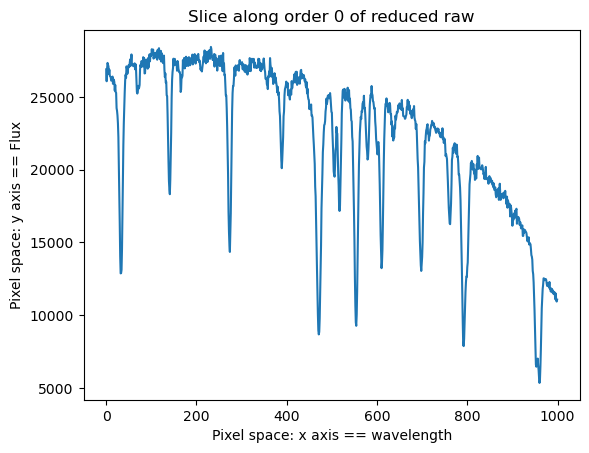

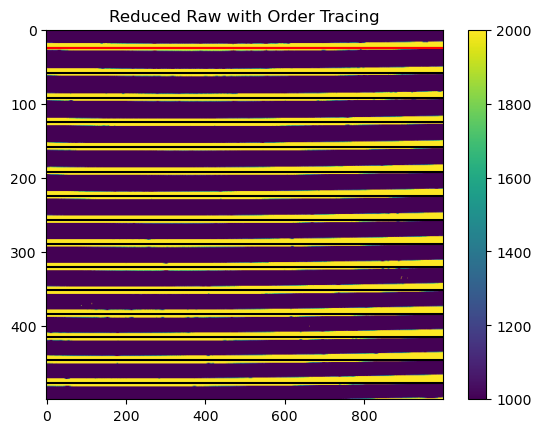

In [191]:
order_index = 0
order_row_pixel = order_pixel_values[order_index]
#print(order_row_pixel)

orderslice = reduced_raw[order_row_pixel,:]
#print(orderslice)

plt.plot(orderslice)
plt.title('Slice along order ' + str(order_index) + ' of reduced raw')
plt.xlabel('Pixel space: x axis == wavelength')
plt.ylabel('Pixel space: y axis == Flux')
plt.show()

# Overplot the order trace on the Dark-Subtract Raw image.
plt.imshow(reduced_raw,vmin=1000,vmax=2000, aspect='auto')
for line in order_pixel_values:
    #plt.plot([0,4000],[line,line])
    plt.axhline(line,color='k')
plt.axhline(order_row_pixel,color='r')
plt.title('Reduced Raw with Order Tracing')
plt.colorbar()
plt.show()

Due to the curvature across the CCD the order slice, if held horizontal, does not cpature the full order.
Instead need to build up the order trace either side of the central vertical slice.


Fitted parameters: Amplitude=29325.41, Mean=23.97, Sigma=2.52


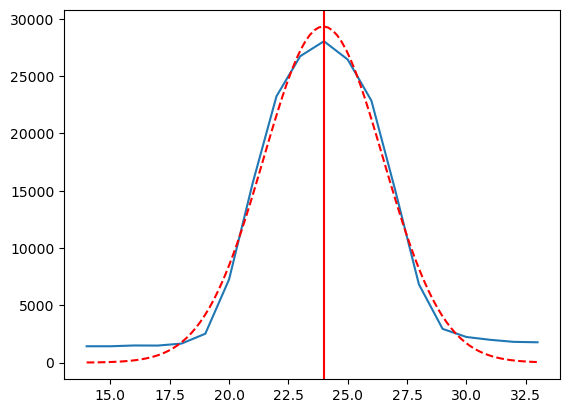

In [ ]:
# Trace slice after centre vertical
centre_column = 2250. #Where the frist vertical slice is made to capture all the orders
col_step = 50. #Step size in columns to trace the orders


# # Select out vertical profile of order at central columns
# iprof = vertical_slice_pixvector[order_row_pixel-10:order_row_pixel+10]
# order_profile = vertical_slice[iprof]
# order_profile_pixvector = vertical_slice_pixvector[iprof]

# # Fit a gaussian to the profile of the vertical slice. This is a common way to measure the width of a spectral order, which is important for optimal extraction.

# # 3. Fit the curve (p0 is the initial guess for amplitude, mean, stddev)
# amp_guess = max(order_profile)
# mu_guess = order_profile_pixvector[np.argmax(order_profile)]
# sigma_guess = np.std(order_profile_pixvector)
# initial_guess = [amp_guess, mu_guess, sigma_guess]
# popt, _ = curve_fit(gaussian, order_profile_pixvector, order_profile, p0=initial_guess, maxfev=5000)

# # 4. Resulting parameters
# amp, mu, sigma = popt
# print(f"Fitted parameters: Amplitude={amp:.2f}, Mean={mu:.2f}, Sigma={sigma:.2f}")

# # 1. Generate a smooth range for the fit line
# x_fit = np.linspace(min(order_profile_pixvector), max(order_profile_pixvector), 100)

# # 2. Calculate the Gaussian curve using optimized parameters
# # popt contains [amplitude, mean, sigma]
# y_fit = gaussian(x_fit, *popt)

plt.plot(order_profile_pixvector,order_profile)
plt.plot(x_fit, y_fit, 'r--')
plt.axvline(order_row_pixel,color='r')

## Task 4: Extract corresponding order from the Thorium-Argon image

We want to convert the Dark-Subtracted Raw from pixel space to wavelength space. To do this we need to create a map of what pixel corresponds to what wavelength.

This map is created using a set of reference wavelengths for a calibration lamp. A calibration lamp is a light source that contains a gas of known composition for which the elements in the gas have spectral emission features at known wavelengths. For our setup these are the Thorium-Argon (ThAr) lamp and the ThAr reference list or Atlas.

The first step is to extract the location of the ThAr spectral lines in pixel space from a spectral image of light from the ThAr lamp.

Follow these steps:

1. Plot the ThAr image using imshow.
2. Inspect the ThAr image - can you see the orders?
3. Use the same order that you used above for the Dark-Subtracted Raw image and extract the order from the ThAr image. It is the same 'CCD' so we can assume the orders are located in the same place in the ThAr image as in the Dark-Subtracted Raw image. (e.g. order5 = thar[order5index,:]
4. Now plot your order for the ThAr image.

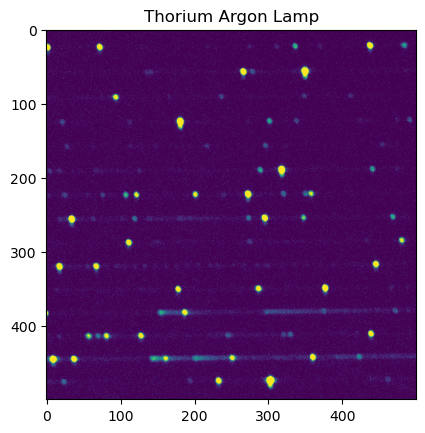

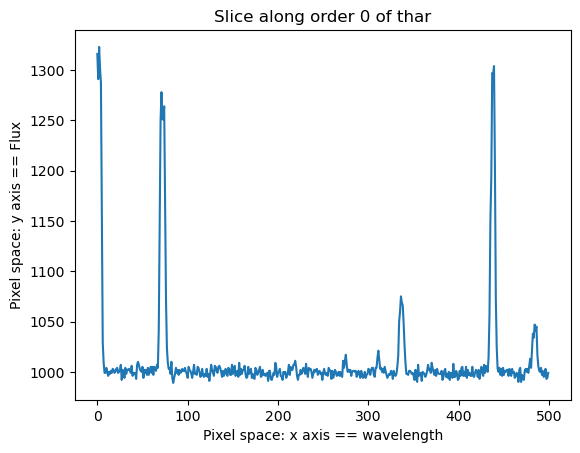

In [83]:
plt.imshow(thar_region,vmin=1000,vmax=1100)
plt.title('Thorium Argon Lamp')
plt.show()

orderslice_thar = thar_region[order_row_pixel,:]
#print(orderslice_thar)

plt.plot(orderslice_thar)
plt.title('Slice along order 0 of thar')
plt.xlabel('Pixel space: x axis == wavelength')
plt.ylabel('Pixel space: y axis == Flux')
plt.show()


You have extracted the flux for your order from your Dark-Subtracted Raw image and from your ThAr image. But they are both in pixel-space. We will now use the ThAr Atlas to map pixels to wavelenght.

## Task 5: Navigating the ThAr Atlas
The ThAr image is the map between pixel-space and wavelength-space. This is because when a ThAr lamp is heated, it emits light at precise, well-known wavelengths that are well-distributed throughout the spectrum.

We then use the ThAr Atlas to match the spectral features in the order of your ThAr image to wavelengths in the Atlas.

The Atlas provided is called ThAr_linelist.txt. Due to pre-processing, the Atlas specifies which ThAr spectral lines are in which orders and gives their corresponding wavelengths.

Follow these steps:
1. Print the ThAr linelist to inspect its column names and contents. Code to read in the linelist is provided in the below cell.
2. Using your order number, extract the list of ThAr lines in your order.

There are a variety of ways to extract the list of ThAr lines:
1. Pandas masking: You can generate a list of True or False values to use as a mask to reduce the pandas dataframe to your required lines. Ask a tutor if you would like to learn how to do this.
2. List comprehension or loops: Loop over the rows of the dataframe either with a For loop, or using comprehension, to test each row to see if it meets your condition i.e. order == order number or order2 == order number.
3. Manual: Copy and paste the wavelengths for your order into a vector in the below cell. (This is not the optimal method if processing multiple orders.)

NOTE: This list MUST be in wavelength order.

In [40]:
linelist = pd.read_csv('Reduction_1/ThAr_linelist.txt', sep = ' ',index_col=0)
print(linelist)

# Choose the right lines for the order. The symbol | means "or" for pandas, and & means "and". Don't forget your order index starts at 0, but the linelist starts at 1.

thar_linelist_filtered = linelist[(linelist['order']==5)|(linelist['order2']==5)]['wavelength']
print(thar_linelist_filtered)

print(type(thar_linelist_filtered))
# Wavelength values after filtering by order
thar_wavelengths = thar_linelist_filtered#[0]  #['wavelength']

    wavelength  relative_strength  order  order2
0   617.246333           1.307481      1       0
1   619.566185           1.148271      1       0
2   623.154481           1.056983      1       2
3   625.638782           0.727938      2       0
4   628.461022           0.988121      2       0
5   632.326797           0.957632      3       0
6   635.310241           0.949188      3       0
7   636.520340           0.862880      3       0
8   639.521850           1.079357      3       4
9   643.352838           1.081504      4       0
10  645.165937           0.825562      4       0
11  648.892681           0.937789      4       5
12  651.344944           1.030319      5       0
13  653.189382           1.065732      5       0
14  656.463884           1.115329      5       6
15  657.313715           1.006997      5       6
16  661.427497           1.092316      6       0
17  664.078618           1.284752      6       0
18  665.619012           0.953844      6       7
19  669.042293      

## Task 6: Mapping pixels to wavelengths

Now, you need to convert from pixel-space to wavelength-space. 

Follow these steps:
1. Use scipy's signal.find_peaks again to extract the pixel positions of the ThAr lines in your order in the ThAr image. Remember to adjust the height and distance arguments so you extract all pixel values.
2. Replot the ThAr order and now overplot vertical lines at the pixel positions of each ThAr line (as you did when order tracing above)

How many ThAr lines did you find in the Atlas? Does this match the number of ThAr lines you have found in the ThAr order?

Discuss with a tutor/lecturer.


[ 898 1691 2287 3346 3621]


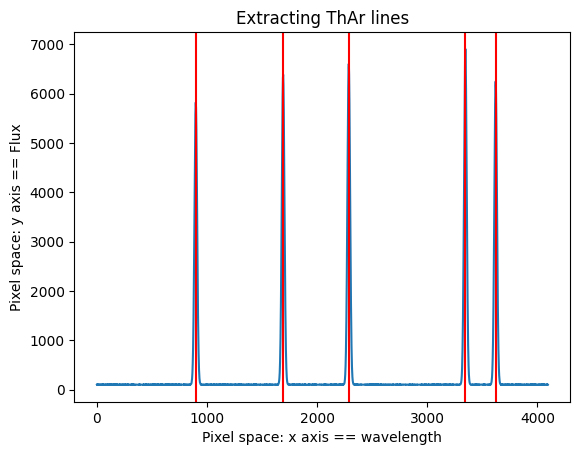

In [41]:
thar_pixel_values, thar_info = sp.signal.find_peaks(orderslice_thar, height=2000, distance = 100)
plt.plot(orderslice_thar)
print(thar_pixel_values)
for line in thar_pixel_values:
    plt.axvline(line, color='r')

plt.title('Extracting ThAr lines')
plt.xlabel('Pixel space: x axis == wavelength')
plt.ylabel('Pixel space: y axis == Flux')
plt.show()


We now have the list of 'x' pixels at which the ThAr lines are located for your order, AND we have the list of wavelengths corresponding to these ThAr lines.

Using these two lists, we will now build a linear equation to convert pixels to wavelengths.

Follow these steps:
1. Plot your list of 'x' pixels against your list of ThAr wavelengths. Is there a clear relation? How would you fit it?
2. Use np.polyfit to fit this relation. Use the pixel positions as your independent variable and their corresponding ThAr wavelengths as the dependent variable. Determine the coefficients for your equation using np.polyfit. What degree polynomial will you use? Thus, how many coefficients do you expect and what is the form of the polynomial?
    e.g. coefficients = np.polyfit(independent variable, dependent variable, deg=?)
3. Now you can use the coefficents to convert all the 'x' pixels in our image to wavelengths. To do this we need a vector of 'x' pixels. HINT: The indices of your flux vector make up your 'x' pixel vector e.g. pixvector = np.arange(0, len(flux), 1)
4. Use your 'x' pixel vector and the coefficients in np.polyval to return the wavelength vector for your order.
    e.g. wavelength_vector = np.polyval(coefficients, x_pixel_vector)
4. You have converted your 'x' pixels tp wavelength. Now plot your order as flux versus wavelength. Don't forget to add labels.

[3.09267543e-03 6.46115610e+02]


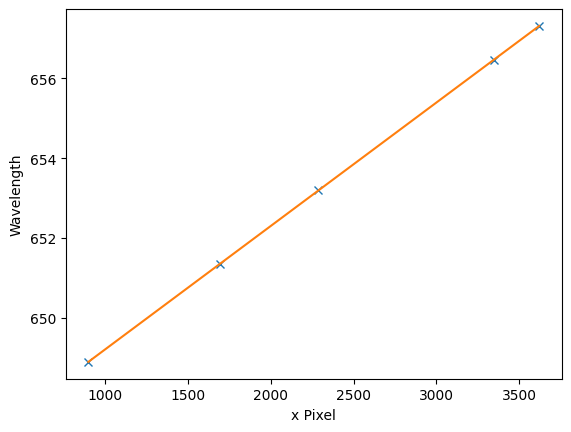

[   0    1    2 ... 4093 4094 4095]
[646.11561012 646.1187028  646.12179548 ... 658.77393066 658.77702334
 658.78011602]


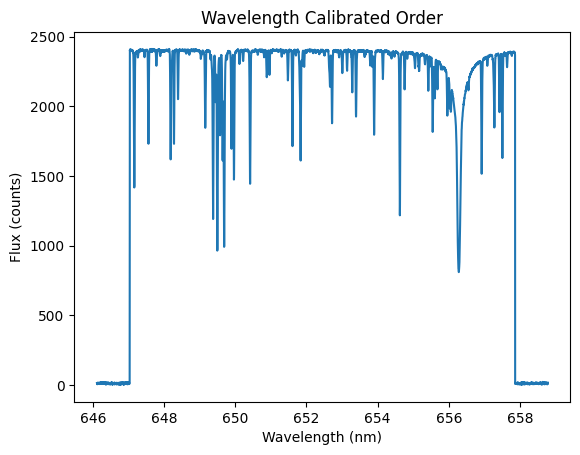

In [48]:
plt.plot(thar_pixel_values, thar_wavelengths, 'x')
plt.xlabel('x Pixel')
plt.ylabel('Wavelength')

coefficients = np.polyfit(thar_pixel_values, thar_linelist_filtered, deg=1)
print(coefficients)

# Extra check for students to confirm fit
fitted_wavelength_vector = np.polyval(coefficients, thar_pixel_values)
plt.plot(thar_pixel_values,fitted_wavelength_vector)
plt.show()

pixel_vector = np.arange(0, len(orderslice_thar), 1)
print(pixel_vector)

wavelength_vector = np.polyval(coefficients, pixel_vector)
print(wavelength_vector)

plt.plot(wavelength_vector,orderslice)
plt.title('Wavelength Calibrated Order')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Flux (counts)')
plt.show()

# Congratulations!

You have successfully wavelength calibrated your order! Now we must check to see if it is correct.

Follow these steps:
1. Overplot the original data from synth_spec.txt and verify the two sets of data align. You may need to modify the scaling of the fluxes.
2. Plot a vertical line using plt.axvline at the centre of the hydrogen line, and another one at 656.28nm. What does this tell us about this spectrum?

## Task 7: Wavelength calibrate all orders

Combine all your code to repeat this process for all 7 orders, and plot them together. How would you produce a full spectrum from this data?